````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/VB_Rotatieveer_uiteinde.py

```
```` 


# Voorbeeld rotatieveer uiteinde

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting -225*SingularityFunction(x, 0, -2) + 50*SingularityFunction(x, 0, -1) - 100*SingularityFunction(x, 3, -1) + 225*SingularityFunction(x, 6, -2) + 50*SingularityFunction(x, 6, -1)
Dwarskrachten 225*SingularityFunction(x, 0, -1) - 50*SingularityFunction(x, 0, 0) + 100*SingularityFunction(x, 3, 0) - 225*SingularityFunction(x, 6, -1) - 50*SingularityFunction(x, 6, 0)
Reactiekrachten {R_6: 50, R_0: 50}
Moment 225*SingularityFunction(x, 0, 0) - 50*SingularityFunction(x, 0, 1) + 100*SingularityFunction(x, 3, 1) - 225*SingularityFunction(x, 6, 0) - 50*SingularityFunction(x, 6, 1)
Hoeverdraaiing -9*SingularityFunction(x, 0, 1)/16 + SingularityFunction(x, 0, 2)/16 - SingularityFunction(x, 3, 2)/8 + 9*SingularityFunction(x, 6, 1)/16 + SingularityFunction(x, 6, 2)/16 + 9/8
Doorbuiging 9*x/8 - 9*SingularityFunction(x, 0, 2)/32 + SingularityFunction(x, 0, 3)/48 - SingularityFunction(x, 3, 3)/24 + 9*SingularityFunction(x, 6, 2)/32 + SingularityFunction(x, 6, 3)/48


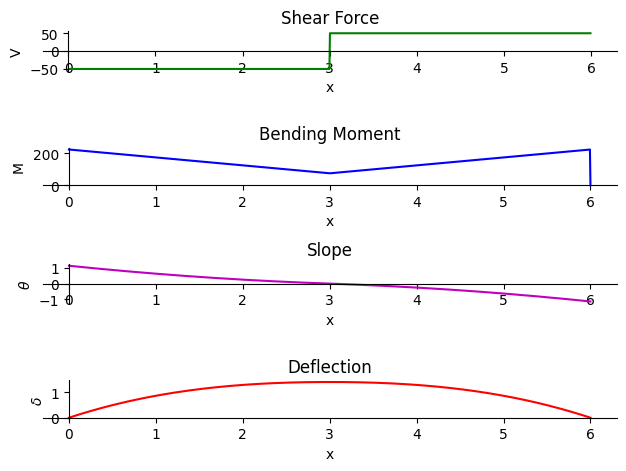

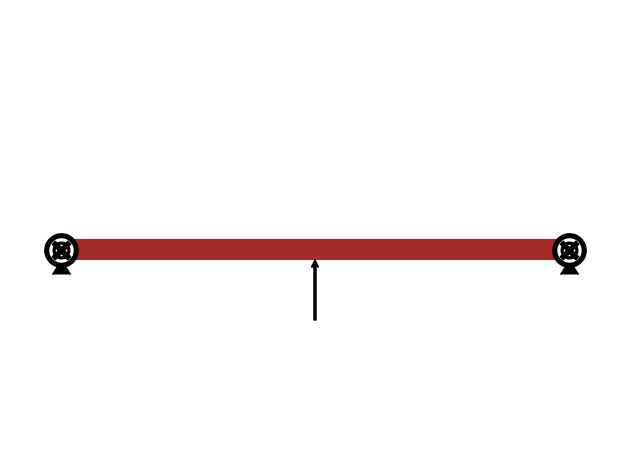

In [2]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols
E, I, k = symbols(['E','I','k'])

#Omschrijving van de balk
b = Beam(6, 20, 20)
r0 = b.apply_support(0,'pin')
r6 = b.apply_support(6,'pin')
b.apply_load(-100, 3, -1)
b.apply_rotation_spring(0, 200)
b.apply_rotation_spring(6, 200)

#berekeningen
b.solve_for_reaction_loads(r0, r6)
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())

#plots
axes = b.plot_loading_results()

d = b.draw()
d.show();